In [1]:
import polars as pl
import numpy as np

In [2]:
df = pl.read_csv(
    "../data/01_raw/swedish_leagues_2011_2025_clean.csv",
    try_parse_dates=True
)
df.head()

date,home_team,away_team,home_goals,away_goals,league,season,matchday,result
date,str,str,i64,i64,str,i64,i64,str
2011-04-02,"""Halmstads BK""","""Kalmar FF""",0,0,"""SE1""",2011,1,"""D"""
2011-04-03,"""IFK Norrköping""","""GAIS""",2,0,"""SE1""",2011,1,"""H"""
2011-04-03,"""Syrianska FC""","""Gefle IF""",1,1,"""SE1""",2011,1,"""D"""
2011-04-03,"""Trelleborgs FF""","""Malmö FF""",2,4,"""SE1""",2011,1,"""A"""
2011-04-03,"""Mjällby AIF""","""Helsingborgs IF""",0,1,"""SE1""",2011,1,"""A"""


In [3]:
df = df.filter(pl.col("league")== "SE1")
df = df.with_columns([
    pl.col("home_goals").cast(pl.Int32),
    pl.col("away_goals").cast(pl.Int32),
])


In [4]:
train_df = df.filter(pl.col("season") <= 2024)
test_df  = df.filter(pl.col("season") == 2025)

latest_date = train_df.select(pl.col("date").max()).item()

train_df = train_df.with_columns(
    (
        (latest_date - pl.col("date"))
        .dt.total_days() / 365
    ).alias("age_years")
)

season_to_id = {
    season: i + 1
    for i, season in enumerate(sorted(train_df["season"].unique()))
}

train_df = train_df.with_columns(
    pl.col("season")
    .replace(season_to_id)
    .alias("season_id")
)

S = len(season_to_id)

In [5]:
train_teams = set(
    pl.concat([
        train_df.select(pl.col("home_team").alias("team")),
        train_df.select(pl.col("away_team").alias("team")),
    ])
    .unique()
    .to_series()
)

test_teams = set(
    pl.concat([
        test_df.select(pl.col("home_team").alias("team")),
        test_df.select(pl.col("away_team").alias("team")),
    ])
    .unique()
    .to_series()
)

test_teams - train_teams

set()

In [6]:
train_teams_series = (
    pl.concat([
        train_df.select(pl.col("home_team").alias("team")),
        train_df.select(pl.col("away_team").alias("team")),
    ])
    .unique()
    .sort("team")
    .to_series()
)

teams = train_teams_series.to_list()
team_to_id = {team: i + 1 for i, team in enumerate(train_teams_series)}
team_to_id

{'AFC Eskilstuna': 1,
 'AIK': 2,
 'BK Häcken': 3,
 'Dalkurd FF': 4,
 'Degerfors IF': 5,
 'Djurgårdens IF': 6,
 'Falkenbergs FF': 7,
 'GAIS': 8,
 'GIF Sundsvall': 9,
 'Gefle IF': 10,
 'Halmstads BK': 11,
 'Hammarby IF': 12,
 'Helsingborgs IF': 13,
 'IF Brommapojkarna': 14,
 'IF Elfsborg': 15,
 'IFK Göteborg': 16,
 'IFK Norrköping': 17,
 'IFK Värnamo': 18,
 'IK Sirius': 19,
 'Jönköpings Södra IF': 20,
 'Kalmar FF': 21,
 'Malmö FF': 22,
 'Mjällby AIF': 23,
 'Syrianska FC': 24,
 'Trelleborgs FF': 25,
 'Varbergs BoIS': 26,
 'Västerås SK': 27,
 'Åtvidabergs FF': 28,
 'Örebro SK': 29,
 'Östers IF': 30,
 'Östersunds FK': 31}

In [7]:
train_df = train_df.with_columns([
    pl.col("home_team")
      .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
      .alias("home_id"),
    pl.col("away_team")
      .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
      .alias("away_id"),
])

test_df = test_df.with_columns([
    pl.col("home_team")
      .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
      .alias("home_id"),
    pl.col("away_team")
      .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
      .alias("away_id"),
])

train_df.select(["home_id", "away_id"]).head()

/tmp/ipykernel_18321/3384498333.py:3: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("home_team").map_elements(lambda x: ...)
with this one instead:
  + pl.col("home_team").replace_strict(team_to_id)

  .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
/tmp/ipykernel_18321/3384498333.py:6: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("away_team").map_elements(lambda x: ...)
with this one instead:
  + pl.col("away_team").replace_strict(team_to_id)

  .map_elements(lambda x: team_to_id[x], return_dtype=pl.Int32)
/tmp/ipykernel_18321/3384498333.py:12: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
On

home_id,away_id
i32,i32
11,21
17,8
24,10
25,22
23,13


In [8]:
xi = 0.3

train_df = train_df.with_columns(
    pl.col("age_years")
    .map_elements(lambda x: np.exp(-xi * x))
    .alias("weight")
)

train_df.select(["age_years", "weight"]).head()

age_years,weight
f64,f64
13.619178,0.01681
13.616438,0.016824
13.616438,0.016824
13.616438,0.016824
13.616438,0.016824


In [9]:
stan_data_train = {
    "N": train_df.height,
    "T": len(train_teams_series),

    "home_team": train_df["home_id"].to_numpy(),
    "away_team": train_df["away_id"].to_numpy(),

    "home_goals": train_df["home_goals"].to_numpy(),
    "away_goals": train_df["away_goals"].to_numpy(),

    "weights": train_df["weight"].to_numpy()
}

stan_data_train["N"], stan_data_train["T"]

(3358, 31)

In [10]:
from cmdstanpy import CmdStanModel 

model = CmdStanModel(
    stan_file="../src/allsvenskan_predictor/stan/poisson_model.stan"
)

/home/mongosaurusrex/personal-projects/allsvenskan-predictor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
20:43:28 - cmdstanpy - INFO - compiling stan file /home/mongosaurusrex/personal-projects/allsvenskan-predictor/src/allsvenskan_predictor/stan/poisson_model.stan to exe file /home/mongosaurusrex/personal-projects/allsvenskan-predictor/src/allsvenskan_predictor/stan/poisson_model
20:43:46 - cmdstanpy - INFO - compiled model executable: /home/mongosaurusrex/personal-projects/allsvenskan-predictor/src/allsvenskan_predictor/stan/poisson_model


In [11]:
fit = model.sample(
    data=stan_data_train,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.9,
    seed=42,
)

20:43:46 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 1:   5%|▌         | 100/2000 [00:01<00:26, 72.05it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:02<00:17, 105.57it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:02<00:14, 118.27it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:03<00:11, 134.96it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:04<00:11, 134.06it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:04<00:09, 143.62it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:05<00:08, 145.03it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:06<00:08, 147.78it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:06<00:07, 147.76it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:07<00:06, 146.69it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:08<00:06, 147.34it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:08<00:05, 141.91it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [00:09<00:05, 128.85it/s, (Sampling)]


chain 1:  70%|███████   | 1400/2000 [


20:44:04 - cmdstanpy - INFO - CmdStan done processing.
20:44:04 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'poisson_model.stan', line 40, column 2 to column 39)
Consider re-running with show_console=True if the above output is unclear!


In [12]:
fit.diagnose()

'Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\nNo divergent transitions found.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nRank-normalized split R-hat values satisfactory for all parameters.\n\nProcessing complete, no problems detected.\n'

In [13]:
summary = fit.summary()

summary.loc[["gamma", "sigma_attack", "sigma_defense"]][
    ["Mean", "StdDev", "R_hat", "ESS_bulk"]
]

,Mean,StdDev,R_hat,ESS_bulk
gamma,0.305343,0.036859,1.000350,4476.54
sigma_attack,0.257417,0.047274,1.001130,2316.44
sigma_defense,0.169106,0.036237,0.999893,2030.69


In [14]:
attack_draws = fit.stan_variable("attack")      # shape (draws, T)
defense_draws = fit.stan_variable("defense")    # shape (draws, T)
gamma_draws = fit.stan_variable("gamma")

In [15]:
attack_mean = attack_draws.mean(axis=0)
attack_lower = np.percentile(attack_draws, 5, axis=0)
attack_upper = np.percentile(attack_draws, 95, axis=0)

defense_mean = defense_draws.mean(axis=0)
defense_lower = np.percentile(defense_draws, 5, axis=0)
defense_upper = np.percentile(defense_draws, 95, axis=0)

In [16]:
order_attack = np.argsort(attack_mean)

attack_mean_sorted = attack_mean[order_attack]
attack_lower_sorted = attack_lower[order_attack]
attack_upper_sorted = attack_upper[order_attack]
teams_sorted_attack = np.array(teams)[order_attack]

order_defense = np.argsort(defense_mean)

defense_mean_sorted = defense_mean[order_defense]
defense_lower_sorted = defense_lower[order_defense]
defense_upper_sorted = defense_upper[order_defense]
teams_sorted_defense = np.array(teams)[order_defense]


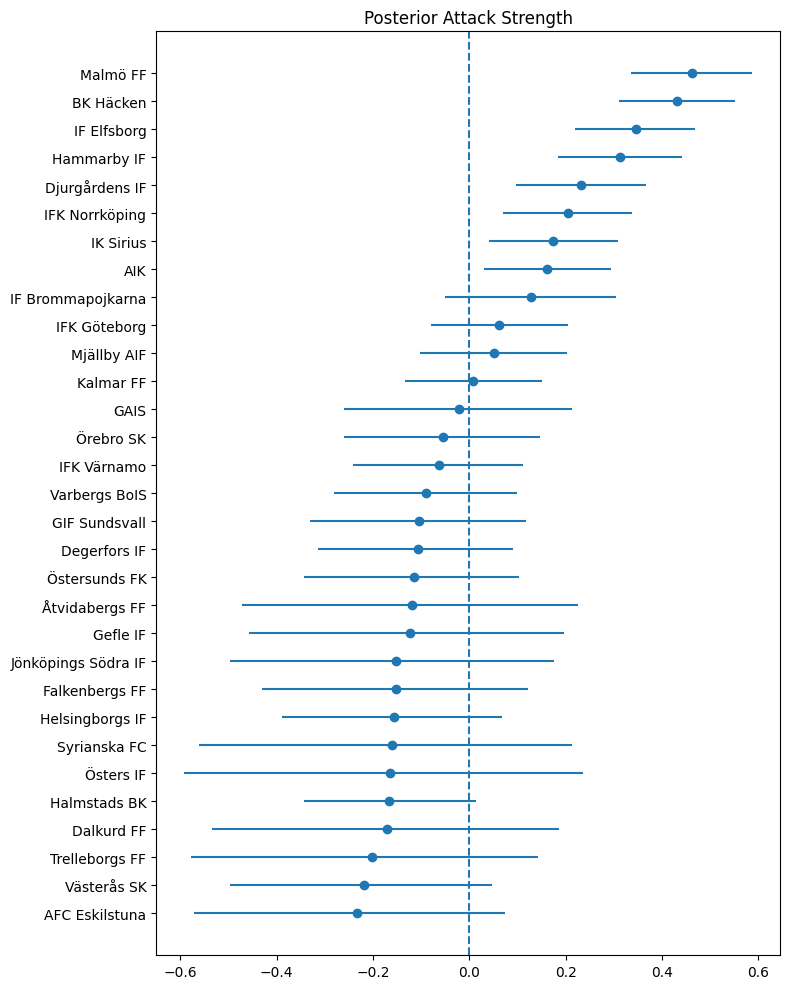

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

plt.errorbar(
    attack_mean_sorted,
    range(len(teams)),
    xerr=[
        attack_mean_sorted - attack_lower_sorted,
        attack_upper_sorted - attack_mean_sorted
    ],
    fmt="o"
)

plt.yticks(range(len(teams)), teams_sorted_attack)
plt.axvline(0, linestyle="--")
plt.title("Posterior Attack Strength")
plt.tight_layout()
plt.show()

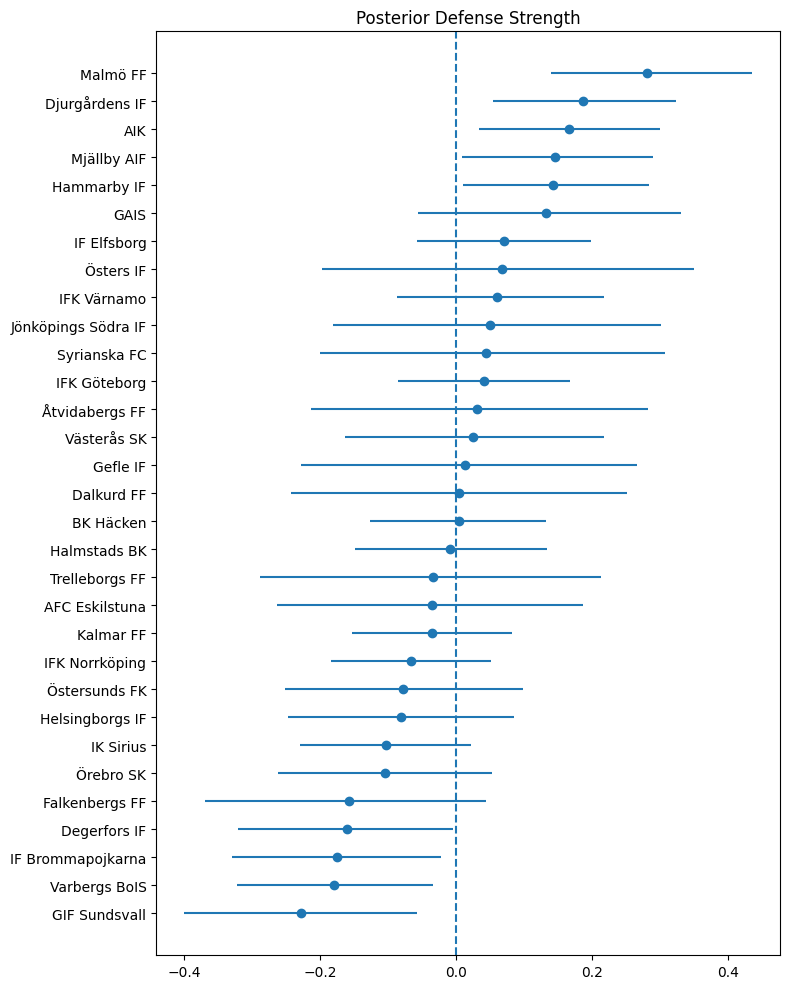

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

plt.errorbar(
    defense_mean_sorted,
    range(len(teams)),
    xerr=[
        defense_mean_sorted - defense_lower_sorted,
        defense_upper_sorted - defense_mean_sorted
    ],
    fmt="o"
)

plt.yticks(range(len(teams)), teams_sorted_defense)
plt.axvline(0, linestyle="--")
plt.title("Posterior Defense Strength")
plt.tight_layout()
plt.show()

In [19]:
# %%
from scipy.stats import skellam
import numpy as np

def predict_match(home_id, away_id):

    h = home_id - 1
    a = away_id - 1

    lambda_home = np.exp(
        attack_draws[:, h]
        - defense_draws[:, a]
        + gamma_draws
    )

    lambda_away = np.exp(
        attack_draws[:, a]
        - defense_draws[:, h]
    )

    p_home = 1 - skellam.cdf(0, lambda_home, lambda_away)
    p_draw = skellam.pmf(0, lambda_home, lambda_away)
    p_away = skellam.cdf(-1, lambda_home, lambda_away)

    return (
        p_home.mean(),
        p_draw.mean(),
        p_away.mean()
    )


predictions = []

for row in test_df.iter_rows(named=True):
    ph, pd, pa = predict_match(row["home_id"], row["away_id"])
    predictions.append((ph, pd, pa))

predictions = np.array(predictions)

In [20]:
y_true = []

for r in test_df["result"]:
    if r == "H":
        y_true.append([1, 0, 0])
    elif r == "D":
        y_true.append([0, 1, 0])
    else:
        y_true.append([0, 0, 1])

y_true = np.array(y_true)

In [21]:
eps = 1e-12  # numerical stability

log_loss = -np.mean(
    np.sum(y_true * np.log(predictions + eps), axis=1)
)

log_loss

np.float64(1.054086608922191)

In [22]:
pred_class = np.argmax(predictions, axis=1)
true_class = np.argmax(y_true, axis=1)

correct = pred_class == true_class

In [23]:
correct.mean()

np.float64(0.4666666666666667)

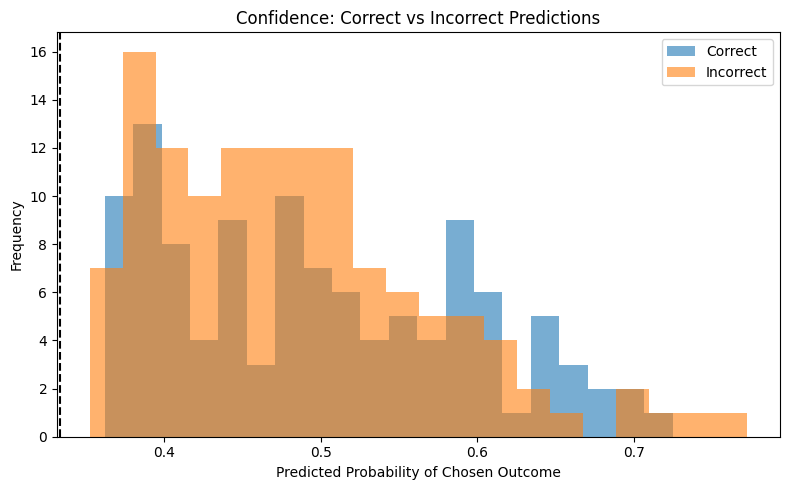

In [24]:
pred_confidence = predictions[np.arange(len(predictions)), pred_class]
conf_correct = pred_confidence[correct]
conf_incorrect = pred_confidence[~correct]

plt.figure(figsize=(8, 5))

plt.hist(conf_correct, bins=20, alpha=0.6, label="Correct")
plt.hist(conf_incorrect, bins=20, alpha=0.6, label="Incorrect")

plt.axvline(1/3, linestyle="--", color="black")
plt.legend()
plt.xlabel("Predicted Probability of Chosen Outcome")
plt.ylabel("Frequency")
plt.title("Confidence: Correct vs Incorrect Predictions")
plt.tight_layout()
plt.show()

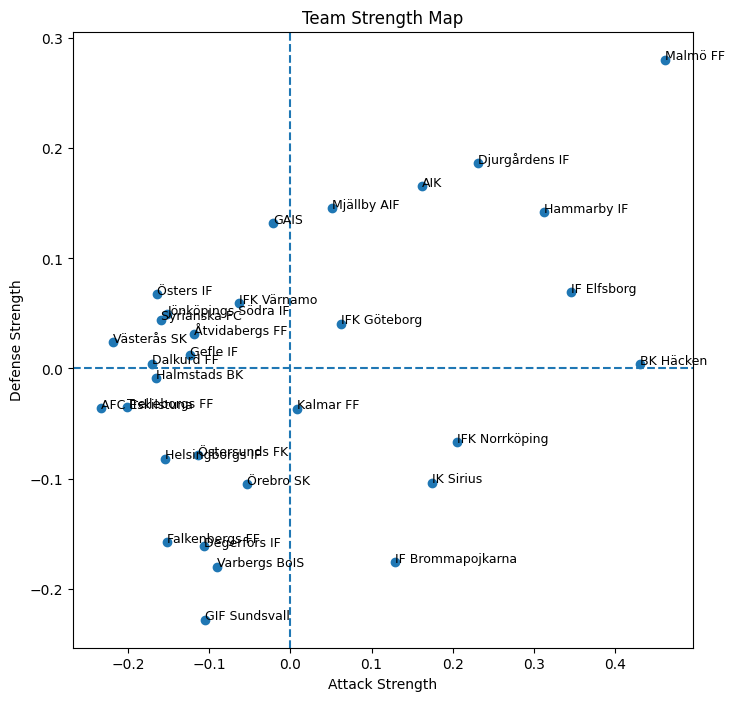

In [25]:
import matplotlib.pyplot as plt

attack_mean = attack_draws.mean(axis=0)
defense_mean = defense_draws.mean(axis=0)

plt.figure(figsize=(8,8))

plt.scatter(attack_mean, defense_mean)

for i, team in enumerate(teams):
    plt.text(attack_mean[i], defense_mean[i], team, fontsize=9)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Attack Strength")
plt.ylabel("Defense Strength")
plt.title("Team Strength Map")

plt.show()

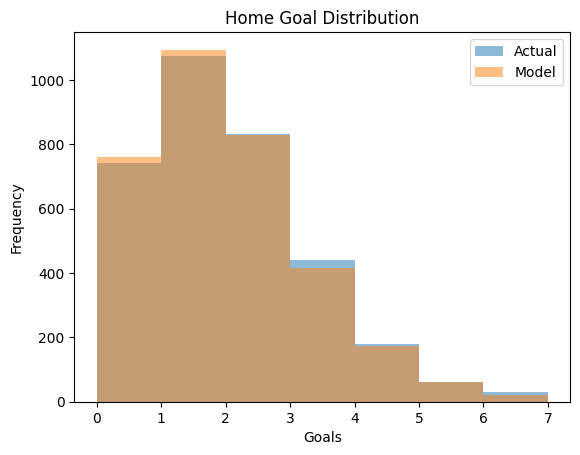

In [31]:
actual_home_goals = train_df["home_goals"].to_numpy()
actual_away_goals = train_df["away_goals"].to_numpy()

lambda_home_mean = []
lambda_away_mean = []

for row in train_df.iter_rows(named=True):

    h = row["home_id"] - 1
    a = row["away_id"] - 1

    lh = np.exp(
        attack_mean[h] - defense_mean[a] + gamma_draws.mean()
    )

    la = np.exp(
        attack_mean[a] - defense_mean[h]
    )

    lambda_home_mean.append(lh)
    lambda_away_mean.append(la)

from scipy.stats import poisson

simulated_goals = []

for lh in lambda_home_mean:
    
    g = poisson.rvs(lh)
    simulated_goals.append(g)

from scipy.stats import poisson

simulated_goals = []

for lh in lambda_home_mean:
    
    g = poisson.rvs(lh)
    simulated_goals.append(g)

plt.hist(actual_home_goals, bins=range(8), alpha=0.5, label="Actual")
plt.hist(simulated_goals, bins=range(8), alpha=0.5, label="Model")

plt.legend()
plt.title("Home Goal Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

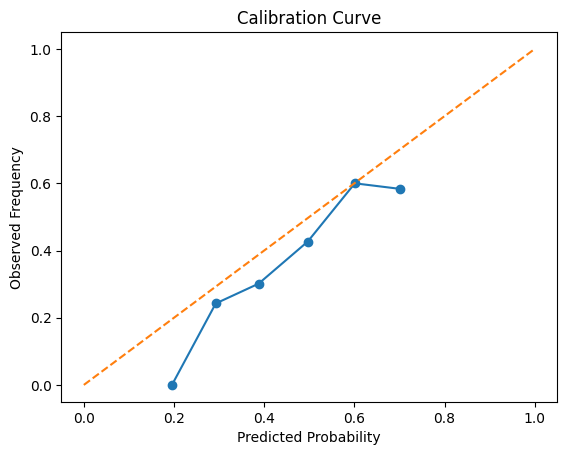

In [29]:
pred_home = predictions[:,0]
true_home = (test_df["result"] == "H").to_numpy()

bins = np.linspace(0,1,10)

digitized = np.digitize(pred_home, bins)

observed = []
predicted = []

for b in range(1,len(bins)):
    
    mask = digitized == b
    
    if mask.sum() > 0:
        observed.append(true_home[mask].mean())
        predicted.append(pred_home[mask].mean())

plt.plot(predicted, observed, marker="o")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")

plt.show()

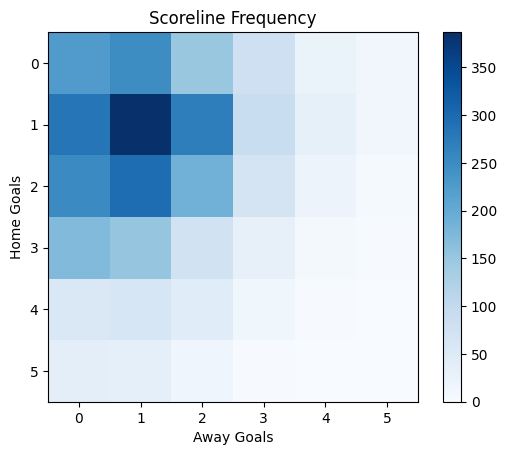

In [30]:
score_matrix = np.zeros((6,6))

for row in train_df.iter_rows(named=True):

    hg = min(row["home_goals"],5)
    ag = min(row["away_goals"],5)

    score_matrix[hg,ag] += 1

plt.imshow(score_matrix, cmap="Blues")

plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.title("Scoreline Frequency")

plt.colorbar()

plt.show()